# Hari 3-4 — Data Pendukung & Data Understanding Lanjutan

**Recap keputusan dari Hari 2 (Project Charter):**
- Level agregasi: **nasional**
- Horizon prediksi: **1 minggu**
- Mau menambah data vaksinasi: **ya**

Notebook ini punya dua bagian: **Bagian A (Hari 3)** — menemukan & menyiapkan data vaksinasi, dan **Bagian B (Hari 4)** — menggabungkan dengan data kasus lalu profiling awal gabungan keduanya.

---
# BAGIAN A — Hari 3: Menemukan Data Pendukung (Vaksinasi)

## Sumber Data yang Direkomendasikan

Repo GitHub **`zakiego/dataset-sebaran-covid19goid`** — mirror dari data resmi **covid19.go.id** (Satgas COVID-19 Indonesia), sudah dalam bentuk CSV siap pakai, granularitas **harian tingkat nasional** (cocok dengan scope proyekmu):

- Data vaksinasi harian nasional: `https://github.com/zakiego/dataset-sebaran-covid19goid/blob/main/nasional/vaksinasi.csv`
- Data kasus harian nasional: `https://github.com/zakiego/dataset-sebaran-covid19goid/blob/main/nasional/harian.csv`

**Cara download:** buka link di atas → klik tombol **Raw** → klik kanan → **Save As** → simpan sebagai `vaksinasi.csv` dan `harian.csv`. (Download otomatis lewat kode diblokir oleh GitHub untuk file ini, jadi manual saja — cukup sekali di awal.)

**Kolom yang ada di `vaksinasi.csv`** (dari preview repo):
`key_as_string` (tanggal), `key` (timestamp epoch), `doc_count`, `jumlah_vaksinasi_1` (dosis 1 harian), `jumlah_vaksinasi_2` (dosis 2 harian), `jumlah_jumlah_vaksinasi_1_kum` (kumulatif dosis 1), `jumlah_jumlah_vaksinasi_2_kum` (kumulatif dosis 2)

**Kolom `harian.csv`** kemungkinan besar berpola serupa (`key_as_string` + `jumlah_positif`, `jumlah_sembuh`, `jumlah_meninggal`, `jumlah_dirawat`, dst) — kita cek langsung dengan `df.columns` setelah load, jangan berasumsi dulu.

## Kenapa Pindah Sumber dari Kaggle (Hari 1-2) ke covid19.go.id?

Dataset Kaggle yang dipakai di Hari 1-2 levelnya **per-provinsi**, sehingga untuk dapat angka nasional kamu harus menjumlahkan manual. Dataset `covid19.go.id` ini sudah **native nasional** dan — yang lebih penting — **berasal dari sumber yang sama** dengan data vaksinasi. Ini menghindari masalah *data konsisten* (metodologi pelaporan yang beda antar sumber bisa bikin angka sulit dibandingkan).

> Notebook Hari 1-2 kamu tetap valid sebagai latihan konsep — mulai Hari 3 ini kita pindah ke sumber data final untuk proyek.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Muat data vaksinasi (sesuaikan path jika perlu)
vaksin = pd.read_csv("vaksinasi.csv")
print("Kolom vaksinasi.csv:", list(vaksin.columns))
print("Jumlah baris:", len(vaksin))
vaksin.head()

Kolom vaksinasi.csv: ['key_as_string', 'key', 'doc_count', 'jumlah_vaksinasi_2', 'jumlah_vaksinasi_1', 'jumlah_jumlah_vaksinasi_1_kum', 'jumlah_jumlah_vaksinasi_2_kum']
Jumlah baris: 693


,key_as_string,key,doc_count,jumlah_vaksinasi_2,jumlah_vaksinasi_1,jumlah_jumlah_vaksinasi_1_kum,jumlah_jumlah_vaksinasi_2_kum
0,2021-02-01,1612137600000,1,0,0,0,0
1,2021-02-02,1612224000000,0,0,0,0,0
2,2021-02-03,1612310400000,0,0,0,0,0
3,2021-02-04,1612396800000,0,0,0,0,0
4,2021-02-05,1612483200000,0,0,0,0,0


In [2]:
# Muat data kasus harian nasional
kasus = pd.read_csv("harian.csv")
print("Kolom harian.csv:", list(kasus.columns))
print("Jumlah baris:", len(kasus))
kasus.head()

Kolom harian.csv: ['key_as_string', 'key', 'doc_count', 'jumlah_meninggal', 'jumlah_sembuh', 'jumlah_positif', 'jumlah_dirawat', 'jumlah_positif_kum', 'jumlah_sembuh_kum', 'jumlah_meninggal_kum', 'jumlah_dirawat_kum']
Jumlah baris: 1029


,key_as_string,key,doc_count,jumlah_meninggal,jumlah_sembuh,jumlah_positif,jumlah_dirawat,jumlah_positif_kum,jumlah_sembuh_kum,jumlah_meninggal_kum,jumlah_dirawat_kum
0,2020-03-02T00:00:00.000Z,1583107200000,1,0,0,2,2,2,0,0,2
1,2020-03-03T00:00:00.000Z,1583193600000,1,0,0,0,0,2,0,0,2
2,2020-03-04T00:00:00.000Z,1583280000000,1,0,0,0,0,2,0,0,2
3,2020-03-05T00:00:00.000Z,1583366400000,1,0,0,0,0,2,0,0,2
4,2020-03-06T00:00:00.000Z,1583452800000,1,0,0,2,2,4,0,0,4


**Cek dulu output dua cell di atas sebelum lanjut.** Kalau nama kolom tanggalnya ternyata bukan `key_as_string`, sesuaikan nama kolom di cell-cell berikutnya.

---
# BAGIAN B — Hari 4: Data Understanding Lanjutan

Sekarang kita ubah dua dataset ini ke agregat **mingguan** (sesuai horizon prediksi dari Project Charter), lalu gabungkan jadi satu tabel.

In [3]:
# Bersihkan & format tanggal
vaksin["Date"] = pd.to_datetime(vaksin["key_as_string"], utc=True)
kasus["Date"] = pd.to_datetime(kasus["key_as_string"], utc=True)

vaksin = vaksin.sort_values("Date").set_index("Date")
kasus = kasus.sort_values("Date").set_index("Date")

print("Rentang data kasus     :", kasus.index.min(), "->", kasus.index.max())
print("Rentang data vaksinasi :", vaksin.index.min(), "->", vaksin.index.max())

Rentang data kasus     : 2020-03-02 00:00:00+00:00 -> 2022-12-25 00:00:00+00:00
Rentang data vaksinasi : 2021-02-01 00:00:00+00:00 -> 2022-12-25 00:00:00+00:00


Perhatikan hasil di atas: vaksinasi di Indonesia baru dimulai **13 Januari 2021**, sedangkan kasus sudah tercatat sejak **awal Maret 2020**. Artinya akan ada ±10 bulan periode di mana data kasus ada tapi data vaksinasi **tidak ada** (karena memang belum ada program vaksinasi). Ini bukan data yang salah/hilang — ini kondisi historis nyata. Catat sebagai temuan data quality; cara menanganinya (potong periode sebelum vaksinasi, atau isi 0) kita putuskan di Hari 8-14 (Data Preparation).

In [14]:
# Resample ke mingguan
kasus_mingguan = kasus["jumlah_positif"].resample("W").sum().rename("kasus_baru_mingguan")

# Untuk vaksinasi, pakai angka kumulatif di akhir tiap minggu (lebih bermakna daripada dijumlah)
vaksin_mingguan = vaksin["jumlah_jumlah_vaksinasi_1_kum"].resample("W").last().rename("vaksin_dosis1_kumulatif")

gabungan = pd.concat([kasus_mingguan, vaksin_mingguan], axis=1)
print(f"Data gabungan: {gabungan.shape[0]} minggu, {gabungan.shape[1]} kolom")
gabungan.head(10)

Data gabungan: 147 minggu, 2 kolom


,kasus_baru_mingguan,vaksin_dosis1_kumulatif
Date,,
2020-03-08 00:00:00+00:00,6,NaN
2020-03-15 00:00:00+00:00,111,NaN
2020-03-22 00:00:00+00:00,397,NaN
2020-03-29 00:00:00+00:00,771,NaN
2020-04-05 00:00:00+00:00,988,NaN
2020-04-12 00:00:00+00:00,1968,NaN
2020-04-19 00:00:00+00:00,2334,NaN
2020-04-26 00:00:00+00:00,2307,NaN
2020-05-03 00:00:00+00:00,2310,NaN


In [5]:
# Cek missing values setelah digabung
print(gabungan.isnull().sum())
print(f"\nJumlah minggu dengan data lengkap (kasus + vaksinasi): {gabungan.dropna().shape[0]} dari {gabungan.shape[0]}")

kasus_baru_mingguan         0
vaksin_dosis1_kumulatif    48
dtype: int64

Jumlah minggu dengan data lengkap (kasus + vaksinasi): 99 dari 147


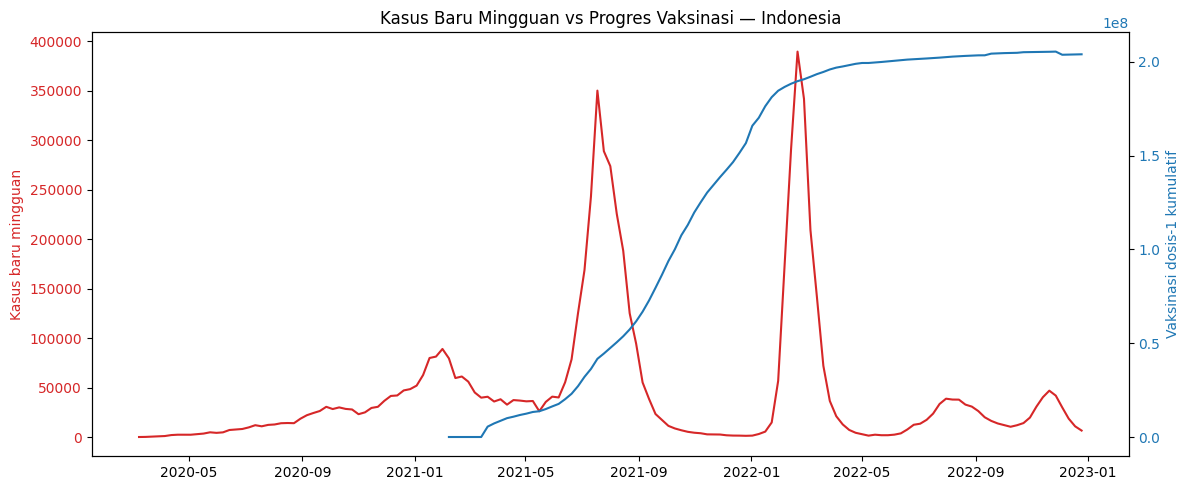

In [6]:
# Visualisasi dua tren berdampingan (dual axis)
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(gabungan.index, gabungan["kasus_baru_mingguan"], color="tab:red", label="Kasus baru/minggu")
ax1.set_ylabel("Kasus baru mingguan", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")

ax2 = ax1.twinx()
ax2.plot(gabungan.index, gabungan["vaksin_dosis1_kumulatif"], color="tab:blue", label="Vaksinasi dosis-1 kumulatif")
ax2.set_ylabel("Vaksinasi dosis-1 kumulatif", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

plt.title("Kasus Baru Mingguan vs Progres Vaksinasi — Indonesia")
fig.tight_layout()
plt.show()

In [7]:
# Korelasi kasar (bukan modeling, sekadar pemahaman awal hubungan dua variabel)
korelasi = gabungan.dropna().corr()
print(korelasi)

                         kasus_baru_mingguan  vaksin_dosis1_kumulatif
kasus_baru_mingguan                 1.000000                -0.214597
vaksin_dosis1_kumulatif            -0.214597                 1.000000


**Peringatan penting soal korelasi ini:** kemungkinan besar angka korelasinya akan terlihat kuat (positif atau negatif), tapi itu **bukan berarti vaksinasi menyebabkan naik/turunnya kasus** secara langsung. Vaksinasi kumulatif itu sifatnya *selalu naik* seiring waktu — sama seperti banyak hal lain yang juga berubah seiring waktu (varian virus, kebijakan PPKM, musim, dll). Ini disebut **spurious correlation** (korelasi semu karena sama-sama terikat waktu). Untuk proyek belajar ini cukup dicatat sebagai insight, bukan kesimpulan sebab-akibat.

## Data Quality Report — Ringkasan Hari 4

Isi ringkasan ini dengan angka hasil eksplorasimu sendiri (isi bagian `[...]`):

| Aspek | Temuan |
|---|---|
| Rentang data kasus | 2020-03-02 00:00:00+00:00 -> 2022-12-25 00:00:00+00:00 |
| Rentang data vaksinasi | 2021-02-01 00:00:00+00:00 -> 2022-12-25 00:00:00+00:00 |
| Jumlah minggu data lengkap (bisa dipakai model) | 99 dari 147 |
| Missing values | Wajar terjadi di periode sebelum Jan 2021 (belum ada program vaksinasi) |
| Potensi masalah lain | lonjakan aneh |

## Refleksi & Keputusan Hari 4

Isi bagian ini — akan dipakai sebagai dasar Data Preparation di Hari 8-14:

> 1. Untuk periode sebelum vaksinasi dimulai (sebelum Jan 2021), datanya mau: dipotong dari dataset / diisi angka 0 → diisi angka 0
> 2. Fitur vaksinasi yang dipakai: hanya dosis-1 / dosis-1 & dosis-2 / persentase populasi tervaksin → persentase populasi tervaksin
> 3. Ada pola aneh di grafik yang perlu dicatat untuk dibersihkan nanti (misal lonjakan/penurunan tajam)? → lonjakan

---
### Selanjutnya: Hari 5-7 — EDA Mendalam
Dengan data gabungan yang sudah lebih dikenal ini, Hari 5-7 fokus ke eksplorasi lebih dalam: pola musiman/gelombang kasus, deteksi outlier terperinci, dan distribusi statistik — sebelum masuk ke Data Preparation penuh di Minggu 2.